# Addis fAbs vs FTIR-EC — the offset, what it takes to fix it, and three regressions

Companion to `addis_fabs_ec_deming.ipynb`. Here we isolate the **offset** (the ~28 Mm⁻¹ intercept),
state exactly **what correction to EC would remove it and by how much**, and show **three regressions
side by side**:

1. **Raw** — fAbs vs FTIR-EC as measured (the offset is visible).
2. **Additive correction** — EC + Δ (a constant µg/m³ added to every filter).
3. **Multiplicative correction** — EC × k (every filter scaled by the same factor).

Each panel is re-fit with OLS so the comparison is fair, and we read off what happens to the intercept.

**Scope: Addis only — not Delhi** (Warren's caution; Delhi has no near-origin points).

## The key algebra — why the *form* of the correction matters

The OLS y-intercept is `b = ȳ − slope·x̄`. Watch what each correction does to it:

- **Additive** `EC → EC + Δ`: translating x left/right does **not** change the OLS slope, and the
  re-fit intercept becomes `b − slope·Δ`. Setting it to zero gives **Δ = b / slope**. So a constant
  additive shift *can* zero the offset while keeping the slope.
- **Multiplicative** `EC → k·EC`: scaling x divides the slope by `k` but leaves the intercept
  **unchanged** (`ȳ − (slope/k)·(k·x̄) = ȳ − slope·x̄ = b`). So a pure multiplier **cannot** remove the
  offset — it only flattens the slope (the apparent MAC).

This is the precise answer to "constant or multiplier?": **only a constant additive shift can drive the
intercept to zero.** A multiplicative error in EC would change the MAC, not create or remove an offset.
The "≈2.4×" figure is just the additive shift expressed as a ratio *at the mean EC* — it is not a
correction that actually zeros the offset.

In [1]:
import sys, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, '../ftir_hips_chem/scripts')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from config import MAC_VALUE
from data_matching import (
    load_aethalometer_data, load_filter_data,
    add_base_filter_id, match_all_parameters,
)
from plotting import PlotConfig          # applies the white-background default style

SITE_NAME, SITE_CODE = 'Addis_Ababa', 'ETAD'

aeth = load_aethalometer_data()
filters = add_base_filter_id(load_filter_data())
matched = match_all_parameters(SITE_NAME, SITE_CODE, aeth[SITE_NAME], filters)

df = matched.dropna(subset=['hips_fabs', 'ftir_ec']).copy()
df['fabs_mm'] = df['hips_fabs'] * MAC_VALUE      # recover Mm⁻¹
df['ec'] = df['ftir_ec']                          # µg/m³
df = df[['date', 'ec', 'fabs_mm']].reset_index(drop=True)

x = df['ec'].values
y = df['fabs_mm'].values
print(f"n = {len(df)} paired Addis filters | mean EC = {x.mean():.2f} µg/m³ | mean fAbs = {y.mean():.2f} Mm⁻¹")

Loaded Beijing: 590 records, 2022-02-23 to 2024-10-07
Loaded Delhi: 289 records, 2022-06-27 to 2024-07-01
Loaded JPL: 765 records, 2021-11-08 to 2024-08-14
Loaded Addis_Ababa: 515 records, 2022-12-06 to 2024-09-22

Total sites loaded: 4
Filter dataset loaded: 44493 measurements
Sites: ['CHTS' 'ETAD' 'INDH' 'USPA']
Date range: 2013-06-28 to 2024-12-08


n = 189 paired Addis filters | mean EC = 5.09 µg/m³ | mean fAbs = 48.76 Mm⁻¹


## Derivations — each correction worked separately

We transform the x-variable (EC) and ask what happens to the OLS fit. Start from the estimators, with
deviations measured from the means:

$$S_{xx}=\sum_i (x_i-\bar{x})^2,\qquad S_{xy}=\sum_i (x_i-\bar{x})(y_i-\bar{y}),$$
$$\text{slope } m=\frac{S_{xy}}{S_{xx}},\qquad \text{intercept } b=\bar{y}-m\,\bar{x}.$$

The intercept is just the fitted fAbs at EC = 0. The whole story below turns on **how each transform
changes the deviations $(x_i-\bar{x})$** — because the slope depends only on those, while the intercept
depends on the slope and the mean $\bar{x}$.

In [2]:
# Foundation: the OLS pieces, computed by hand so the derivations can be checked
xbar, ybar = x.mean(), y.mean()
Sxx = np.sum((x - xbar) ** 2)
Sxy = np.sum((x - xbar) * (y - ybar))
slope = Sxy / Sxx
offset = ybar - slope * xbar
print(f"Sxx = {Sxx:.2f}   Sxy = {Sxy:.2f}")
print(f"slope  m = Sxy/Sxx        = {slope:.4f}  Mm⁻¹ per µg/m³")
print(f"offset b = ȳ - m·x̄        = {offset:.4f}  Mm⁻¹")
print(f"(np.polyfit check: slope {np.polyfit(x, y, 1)[0]:.4f}, intercept {np.polyfit(x, y, 1)[1]:.4f})")

Sxx = 1002.61   Sxy = 4004.81
slope  m = Sxy/Sxx        = 3.9944  Mm⁻¹ per µg/m³
offset b = ȳ - m·x̄        = 28.4157  Mm⁻¹
(np.polyfit check: slope 3.9944, intercept 28.4157)


### 1. Additive correction:  $x' = x + \Delta$

A constant shift moves the mean by the same amount, so the **deviations are unchanged**:
$$\bar{x}' = \bar{x}+\Delta,\qquad x_i'-\bar{x}' = (x_i+\Delta)-(\bar{x}+\Delta)=x_i-\bar{x}.$$
Hence $S_{x'x'}=S_{xx}$ and $S_{x'y}=S_{xy}$, giving

$$\boxed{m' = \frac{S_{x'y}}{S_{x'x'}} = \frac{S_{xy}}{S_{xx}} = m}\quad(\text{slope unchanged}),$$
$$\boxed{b' = \bar{y}-m'\,\bar{x}' = \bar{y}-m(\bar{x}+\Delta) = b - m\,\Delta.}$$

Set $b'=0$:  $\;\Delta = \dfrac{b}{m} = \dfrac{28.42}{3.99} \approx 7.11\ \mu g/m^3.$ **The offset can be removed,
and the slope (MAC) is preserved.**

In [3]:
Delta = offset / slope
mp, bp = np.polyfit(x + Delta, y, 1)
print(f"Δ = b/m = {Delta:.4f} µg/m³")
print(f"refit slope     = {mp:.4f}   | predicted m        = {slope:.4f}")
print(f"refit intercept = {bp:.4f}   | predicted b - m·Δ  = {offset - slope*Delta:.4f}")

Δ = b/m = 7.1139 µg/m³
refit slope     = 3.9944   | predicted m        = 3.9944
refit intercept = 0.0000   | predicted b - m·Δ  = 0.0000


### 2. Multiplicative correction:  $x' = k\,x$

Scaling stretches the deviations by $k$:
$$\bar{x}' = k\,\bar{x},\qquad x_i'-\bar{x}' = k\,x_i - k\,\bar{x} = k\,(x_i-\bar{x}).$$
So $S_{x'x'}=k^2 S_{xx}$ and $S_{x'y}=k\,S_{xy}$, giving

$$\boxed{m' = \frac{k\,S_{xy}}{k^2 S_{xx}} = \frac{m}{k}}\quad(\text{slope flattened}),$$
$$\boxed{b' = \bar{y}-m'\,\bar{x}' = \bar{y}-\frac{m}{k}\,(k\,\bar{x}) = \bar{y}-m\,\bar{x} = b.}$$

The intercept is **independent of $k$** — it stays at $b$ for every scaling. **No multiplier can remove
the offset;** it only changes the apparent MAC.

In [4]:
k_demo = 2.40                       # any value works — the intercept won't move
mp, bp = np.polyfit(k_demo * x, y, 1)
print(f"using k = {k_demo}")
print(f"refit slope     = {mp:.4f}   | predicted m/k = {slope/k_demo:.4f}")
print(f"refit intercept = {bp:.4f}   | predicted b   = {offset:.4f}  (unchanged for ANY k)")

using k = 2.4
refit slope     = 1.6643   | predicted m/k = 1.6643
refit intercept = 28.4157   | predicted b   = 28.4157  (unchanged for ANY k)


### 3. Combined / affine correction:  $x' = k\,x + \Delta$

The additive part shifts the mean but **drops out of the deviations**, so the spread behaves exactly
like the pure multiplicative case:
$$\bar{x}' = k\,\bar{x}+\Delta,\qquad x_i'-\bar{x}' = (k x_i+\Delta)-(k\bar{x}+\Delta)=k\,(x_i-\bar{x}).$$
Therefore $m'=m/k$ again, but the mean now carries the $\Delta$:

$$\boxed{b' = \bar{y}-m'\,\bar{x}' = \bar{y}-\frac{m}{k}\,(k\bar{x}+\Delta)
        = \underbrace{(\bar{y}-m\bar{x})}_{b} - \frac{m}{k}\,\Delta = b-\frac{m}{k}\,\Delta.}$$

Set $b'=0$:  $\;\Delta = k\,\dfrac{b}{m} = k\cdot 7.11.$ **The additive term does all the offset-removal;
the multiplier $k$ is free and only sets the resulting slope $m/k$.** Pure additive is just the $k=1$
member of this family.

In [5]:
k_c = 1.5
D_c = k_c * (offset / slope)        # additive the affine fit then needs to hit zero
mp, bp = np.polyfit(k_c * x + D_c, y, 1)
print(f"using k = {k_c}, Δ = k·(b/m) = {D_c:.4f} µg/m³")
print(f"refit slope     = {mp:.4f}   | predicted m/k          = {slope/k_c:.4f}")
print(f"refit intercept = {bp:.4f}   | predicted b - (m/k)·Δ  = {offset - (slope/k_c)*D_c:.4f}")
print(f"constant added to every filter = {D_c:.2f} µg/m³  (> {offset/slope:.2f} for pure additive)")

using k = 1.5, Δ = k·(b/m) = 10.6709 µg/m³
refit slope     = 2.6629   | predicted m/k          = 2.6629
refit intercept = 0.0000   | predicted b - (m/k)·Δ  = 0.0000
constant added to every filter = 10.67 µg/m³  (> 7.11 for pure additive)


## What we need to fix the data — the values

`offset` is the OLS intercept we want to remove. The two candidate corrections and what each does to
the re-fit line:

In [6]:
def deming(x, y, lam):
    x = np.asarray(x, float); y = np.asarray(y, float)
    xb, yb = x.mean(), y.mean()
    sxx = np.sum((x-xb)**2); syy = np.sum((y-yb)**2); sxy = np.sum((x-xb)*(y-yb))
    s = (syy - lam*sxx + np.sqrt((syy - lam*sxx)**2 + 4*lam*sxy**2)) / (2*sxy)
    return s, yb - s*xb

slope, offset = np.polyfit(x, y, 1)
xbar, ybar = x.mean(), y.mean()

Delta = offset / slope            # additive shift (µg/m³) to zero the intercept
k = ybar / (slope * xbar)         # multiplier that lands the mean on the through-origin line

# Re-fit each corrected dataset with OLS
add_slope, add_int = np.polyfit(x + Delta, y, 1)
mul_slope, mul_int = np.polyfit(x * k, y, 1)
dem_slope, dem_int = deming(x, y, (1.0/0.2)**2)   # σ_fAbs=1.0, σ_EC=0.2 -> λ=25

fix = pd.DataFrame([
    {'quantity': 'offset to remove (OLS intercept)', 'value': f'{offset:.2f} Mm⁻¹'},
    {'quantity': 'OLS slope (raw)',                  'value': f'{slope:.2f} Mm⁻¹ per µg/m³'},
    {'quantity': 'additive shift Δ = offset/slope',  'value': f'+{Delta:.2f} µg/m³ on every filter'},
    {'quantity': '  Δ relative to mean EC',          'value': f'{Delta/xbar:.2f}× the mean ({xbar:.2f})'},
    {'quantity': 'multiplier k = ȳ/(slope·x̄)',       'value': f'×{k:.2f} (mean-point ratio only)'},
])
print(fix.to_string(index=False))

print("\nRe-fit result after each correction:")
refit = pd.DataFrame([
    {'correction': 'raw',                 'EC transform': 'EC',         'refit slope': round(slope,3),     'refit intercept (Mm⁻¹)': round(offset,2)},
    {'correction': 'additive (EC+Δ)',     'EC transform': f'EC+{Delta:.2f}', 'refit slope': round(add_slope,3), 'refit intercept (Mm⁻¹)': round(add_int,2)},
    {'correction': 'multiplicative (EC×k)','EC transform': f'EC×{k:.2f}',     'refit slope': round(mul_slope,3), 'refit intercept (Mm⁻¹)': round(mul_int,2)},
])
print(refit.to_string(index=False))

                        quantity                         value
offset to remove (OLS intercept)                    28.42 Mm⁻¹
                 OLS slope (raw)           3.99 Mm⁻¹ per µg/m³
 additive shift Δ = offset/slope   +7.11 µg/m³ on every filter
           Δ relative to mean EC         1.40× the mean (5.09)
     multiplier k = ȳ/(slope·x̄) ×2.40 (mean-point ratio only)

Re-fit result after each correction:
           correction EC transform  refit slope  refit intercept (Mm⁻¹)
                  raw           EC        3.994                   28.42
      additive (EC+Δ)      EC+7.11        3.994                    0.00
multiplicative (EC×k)      EC×2.40        1.667                   28.42


**Read-out.** The additive correction drives the intercept to ~0 while keeping the slope at ~4.
The multiplicative correction leaves the intercept at ~28 and merely flattens the slope — confirming
the algebra above. So "fixing the data" to remove the offset requires a **constant ~7 µg/m³**
on every filter, which is larger than the mean EC itself — physically hard to justify as uniform
missing char.

### Where the ×2.40 comes from — it's the additive shift in disguise

The multiplier `k = ȳ / (slope·x̄)` is **not an independent correction** — it is the additive shift
re-expressed as a ratio *at the mean filter*:

$$k \;=\; \frac{\bar{y}}{\text{slope}\cdot\bar{x}}
      \;=\; \frac{\bar{x} + \Delta}{\bar{x}}
      \;=\; 1 + \frac{\Delta}{\bar{x}}.$$

Concretely for Addis: the mean fAbs (48.76) sits on a slope-3.99 line at EC = ȳ/slope =
48.76 / 3.99 = **12.21 µg/m³**, but the measured mean EC is only **5.09**. To land the mean point on a
through-origin line you must move EC **5.09 → 12.21**, i.e. either add Δ = 12.21 − 5.09 = **+7.11**, or
scale by 12.21 / 5.09 = **×2.40**. Same move of the mean point — so `k = 1 + 7.11/5.09 = 2.40`.

The two agree **only at the mean**. Away from it they differ completely: +7.11 moves every filter
equally (a slide → intercept → 0), while ×2.40 moves each filter by 1.40× *its own* EC (a stretch about
EC = 0 → intercept stays 28). The cell below prints the identity.

In [7]:
ec_target = ybar / slope                 # EC at which the slope line reaches mean fAbs
print(f"mean EC (x̄)            = {xbar:.2f} µg/m³")
print(f"mean fAbs (ȳ)          = {ybar:.2f} Mm⁻¹")
print(f"EC target = ȳ/slope    = {ec_target:.2f} µg/m³   (where mean fAbs meets the slope-{slope:.2f} line)")
print(f"additive   Δ = target - x̄  = {ec_target - xbar:.2f} µg/m³")
print(f"multiplier k = target / x̄  = {ec_target / xbar:.3f}")
print(f"identity   1 + Δ/x̄         = {1 + (ec_target - xbar)/xbar:.3f}   (== k)")

mean EC (x̄)            = 5.09 µg/m³
mean fAbs (ȳ)          = 48.76 Mm⁻¹
EC target = ȳ/slope    = 12.21 µg/m³   (where mean fAbs meets the slope-3.99 line)
additive   Δ = target - x̄  = 7.11 µg/m³
multiplier k = target / x̄  = 2.397
identity   1 + Δ/x̄         = 2.397   (== k)


## Three regressions, side by side

Same y-axis (fAbs, Mm⁻¹) throughout; only the x-axis (EC) transform differs. Each panel carries its
own OLS re-fit and stats box.

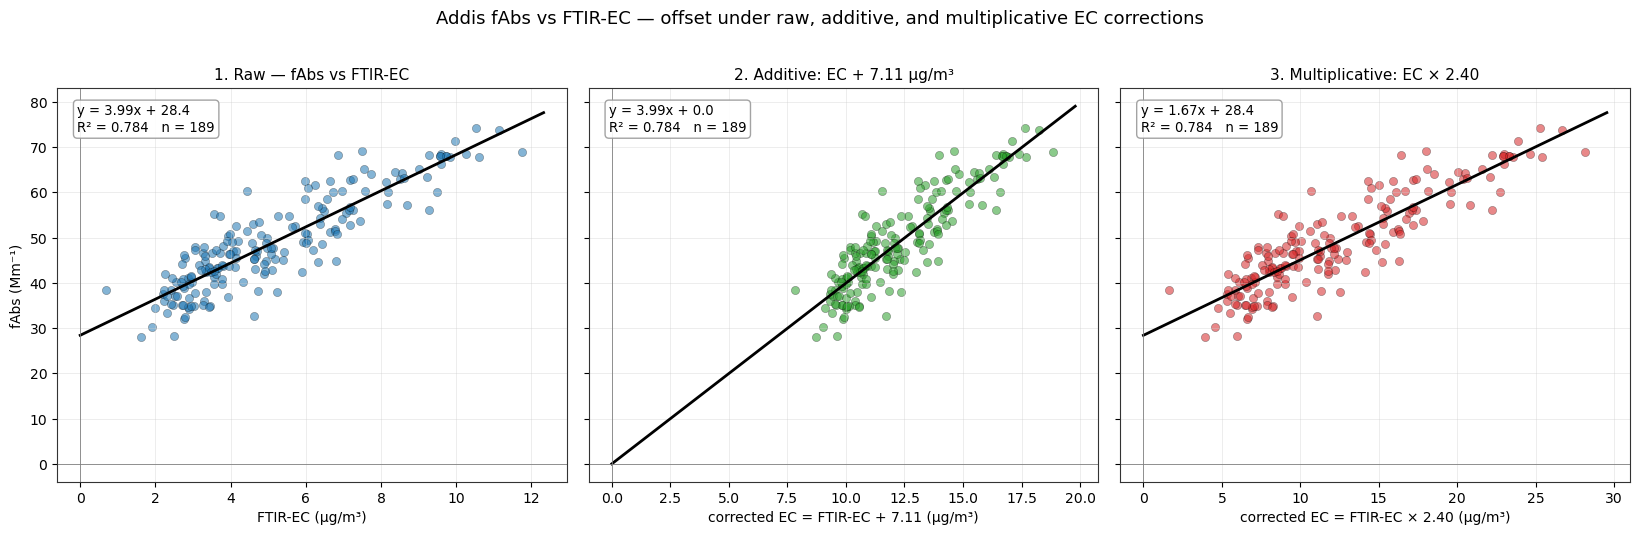

In [8]:
def panel(ax, xv, yv, title, xlabel, color):
    s, b = np.polyfit(xv, yv, 1)
    r = np.corrcoef(xv, yv)[0, 1]
    ax.scatter(xv, yv, s=35, alpha=0.55, edgecolor='k', linewidth=0.3, color=color)
    xx = np.linspace(0, xv.max() * 1.05, 100)
    ax.plot(xx, s * xx + b, color='k', lw=2)
    ax.axhline(0, color='grey', lw=0.6); ax.axvline(0, color='grey', lw=0.6)
    ax.set_xlabel(xlabel); ax.set_title(title, fontsize=11)
    ax.text(0.04, 0.96,
            f"y = {s:.2f}x + {b:.1f}\nR² = {r**2:.3f}   n = {len(xv)}",
            transform=ax.transAxes, va='top', ha='left', fontsize=9.5,
            bbox=dict(boxstyle='round', fc='white', ec='0.6', alpha=0.9))
    return s, b

fig, axes = plt.subplots(1, 3, figsize=(16.5, 5.2), sharey=True)
panel(axes[0], x,           y, '1. Raw — fAbs vs FTIR-EC',
      'FTIR-EC (µg/m³)', 'C0')
panel(axes[1], x + Delta,   y, f'2. Additive: EC + {Delta:.2f} µg/m³',
      f'corrected EC = FTIR-EC + {Delta:.2f} (µg/m³)', 'C2')
panel(axes[2], x * k,       y, f'3. Multiplicative: EC × {k:.2f}',
      f'corrected EC = FTIR-EC × {k:.2f} (µg/m³)', 'C3')
axes[0].set_ylabel('fAbs (Mm⁻¹)')
fig.suptitle('Addis fAbs vs FTIR-EC — offset under raw, additive, and multiplicative EC corrections',
             fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

## Why a multiplier can't remove the offset (the geometry)

It comes down to **what each correction does to the point at EC = 0**, because the intercept is just
"the fitted fAbs when EC = 0."

- **Additive (EC + Δ) is a rigid slide.** Every filter moves the *same* distance to the right, so the
  whole cloud — and the best-fit line with it — translates sideways without tilting. The slope is
  untouched; the line slides down until it crosses the origin. A real "FTIR misses a fixed amount of
  char on every filter" would look exactly like this.

- **Multiplicative (EC × k) is a stretch anchored at EC = 0.** Each filter moves a distance
  *proportional to its own EC*: a 10 µg/m³ filter moves 10× farther than a 1 µg/m³ filter, and a
  filter at EC = 0 doesn't move at all. The fitted line therefore **pivots about its y-intercept** —
  the value at EC = 0 is pinned, so the intercept can't change; only the slope (the apparent MAC)
  gets flatter. Algebraically: new slope = slope/k, new intercept = ȳ − (slope/k)(k·x̄) = ȳ − slope·x̄,
  which is the *same* intercept you started with.

So the intercept is a property of the line's height at EC = 0, and only a horizontal *translation*
(additive) moves that height. A horizontal *scaling* (multiplicative) leaves it fixed. That is the
whole reason the multiplicative panel above still reads 28.4.

The illustration below shows the two motions on a few representative filters (arrows = how far each
point moves).

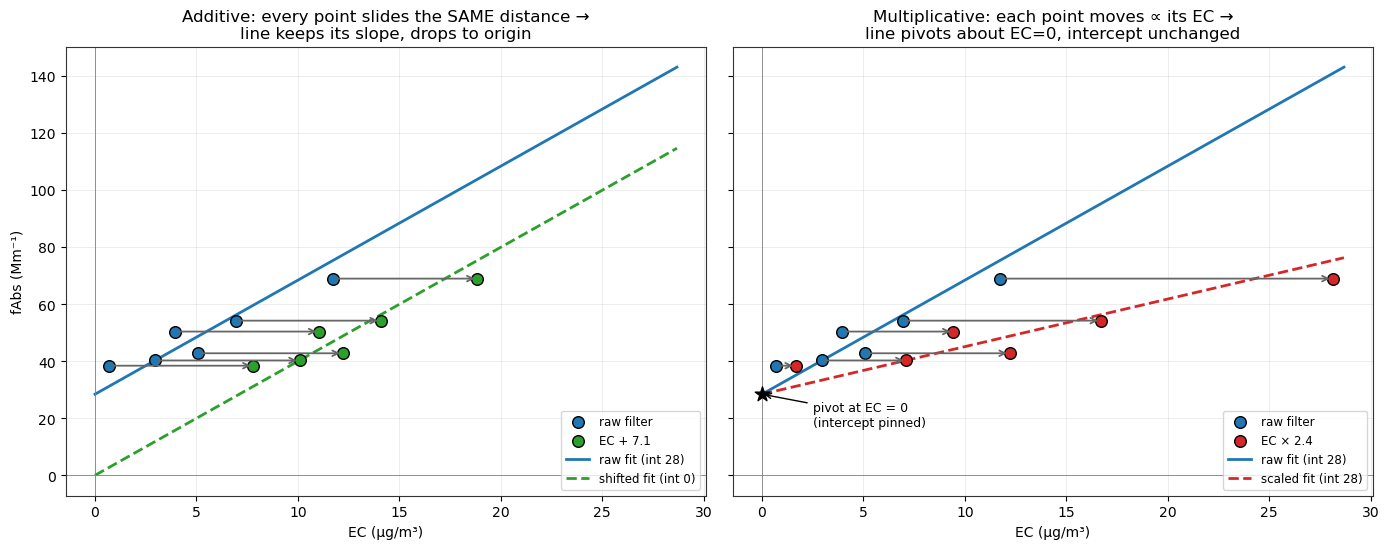

In [9]:
# Pick a few representative filters spanning the EC range, to show how far each moves
idx = np.argsort(x)[np.linspace(0, len(x) - 1, 6).astype(int)]
xs, ys = x[idx], y[idx]
xx = np.linspace(0, (x * k).max() * 1.02, 100)

fig, ax = plt.subplots(1, 2, figsize=(14, 5.6), sharey=True)

# --- Additive: rigid slide (arrows all the same length) ---
ax[0].scatter(xs, ys, s=70, color='C0', edgecolor='k', zorder=3, label='raw filter')
ax[0].scatter(xs + Delta, ys, s=70, color='C2', edgecolor='k', zorder=3, label=f'EC + {Delta:.1f}')
for xi, yi in zip(xs, ys):
    ax[0].annotate('', xy=(xi + Delta, yi), xytext=(xi, yi),
                   arrowprops=dict(arrowstyle='->', color='0.4', lw=1.3))
ax[0].plot(xx, slope * xx + offset, 'C0-', lw=2, label=f'raw fit (int {offset:.0f})')
ax[0].plot(xx, slope * xx, 'C2--', lw=2, label='shifted fit (int 0)')
ax[0].set_title('Additive: every point slides the SAME distance →\nline keeps its slope, drops to origin')
ax[0].set_xlabel('EC (µg/m³)'); ax[0].set_ylabel('fAbs (Mm⁻¹)')

# --- Multiplicative: stretch anchored at EC=0 (arrow length ∝ EC) ---
ax[1].scatter(xs, ys, s=70, color='C0', edgecolor='k', zorder=3, label='raw filter')
ax[1].scatter(xs * k, ys, s=70, color='C3', edgecolor='k', zorder=3, label=f'EC × {k:.1f}')
for xi, yi in zip(xs, ys):
    ax[1].annotate('', xy=(xi * k, yi), xytext=(xi, yi),
                   arrowprops=dict(arrowstyle='->', color='0.4', lw=1.3))
ax[1].plot(xx, slope * xx + offset, 'C0-', lw=2, label=f'raw fit (int {offset:.0f})')
ax[1].plot(xx, mul_slope * xx + mul_int, 'C3--', lw=2, label=f'scaled fit (int {mul_int:.0f})')
ax[1].scatter([0], [offset], s=120, color='k', marker='*', zorder=4)
ax[1].annotate('pivot at EC = 0\n(intercept pinned)', xy=(0, offset), xytext=(2.5, offset - 11),
               fontsize=9, arrowprops=dict(arrowstyle='->', color='k'))
ax[1].set_title('Multiplicative: each point moves ∝ its EC →\nline pivots about EC=0, intercept unchanged')
ax[1].set_xlabel('EC (µg/m³)')

for a in ax:
    a.axhline(0, color='grey', lw=0.6); a.axvline(0, color='grey', lw=0.6)
    a.legend(loc='lower right', fontsize=8.5)
plt.tight_layout(); plt.show()

## Corrected values (first rows)

What the data look like after each correction (shown inline; not written to disk).

In [10]:
out = df.copy()
out['EC + Δ (additive)'] = (out['ec'] + Delta).round(3)
out['EC × k (multiplicative)'] = (out['ec'] * k).round(3)
out = out.rename(columns={'ec': 'FTIR-EC', 'fabs_mm': 'fAbs (Mm⁻¹)'})
out[['date', 'FTIR-EC', 'EC + Δ (additive)', 'EC × k (multiplicative)', 'fAbs (Mm⁻¹)']].head(12)

,date,FTIR-EC,EC + Δ (additive),EC × k (multiplicative),fAbs (Mm⁻¹)
0,2022-12-13,3.048084,10.162,7.305,47.957374
1,2022-12-25,2.755055,9.869,6.603,38.786292
2,2024-08-01,8.150526,15.264,19.533,57.470331
3,2022-12-07,2.547161,9.661,6.104,40.237721
4,2022-12-10,2.784100,9.898,6.672,45.512358
5,2022-12-16,3.044944,10.159,7.297,47.208514
6,2022-12-19,4.444467,11.558,10.652,60.301312
7,2022-12-22,4.148900,11.263,9.943,52.546182
8,2022-12-28,1.625668,8.740,3.896,28.085699
9,2022-12-31,2.220546,9.334,5.322,35.887198


## All sites — fAbs vs FTIR-EC crossplot, anchored at (0, 0)

Re-plotting Addis alongside Beijing, Delhi, and JPL on the same fAbs (Mm⁻¹) vs FTIR-EC (µg/m³) axes,
**both axes starting at the origin** so each site's intercept is visible where its fit line meets
EC = 0 (diamond markers). This shows whether the offset is an Addis quirk or general.

In [11]:
from config import SITES

site_fits = {}
for site, info in SITES.items():
    m = match_all_parameters(site, info['code'], aeth.get(site), filters)
    if m is None:
        continue
    sub = m.dropna(subset=['hips_fabs', 'ftir_ec'])
    if len(sub) < 2:
        continue
    xv = sub['ftir_ec'].values
    yv = (sub['hips_fabs'] * MAC_VALUE).values
    s, b = np.polyfit(xv, yv, 1)
    r = np.corrcoef(xv, yv)[0, 1]
    site_fits[site] = dict(x=xv, y=yv, slope=s, intercept=b, r2=r ** 2,
                           n=len(sub), color=info['color'])

summary = pd.DataFrame([
    {'site': s.replace('_', ' '), 'n': v['n'], 'slope': round(v['slope'], 2),
     'intercept (Mm⁻¹)': round(v['intercept'], 1), 'R²': round(v['r2'], 3),
     'EC range (µg/m³)': f"{v['x'].min():.1f} – {v['x'].max():.1f}"}
    for s, v in site_fits.items()])
print(summary.to_string(index=False))

       site   n  slope  intercept (Mm⁻¹)    R² EC range (µg/m³)
    Beijing 161   5.57               6.2 0.541       -0.4 – 5.7
      Delhi  63   3.82              23.3 0.764      -4.0 – 60.6
        JPL 130   8.14               0.7 0.522        0.1 – 1.1
Addis Ababa 189   3.99              28.4 0.784       0.7 – 11.7


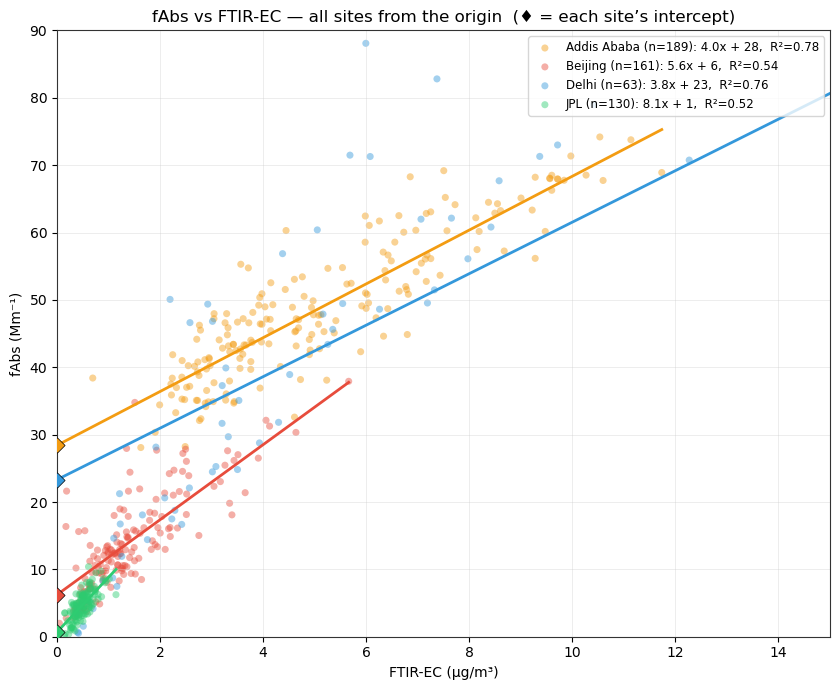

Note: Delhi EC extends to ~60 µg/m³ (off-plot); x-axis capped at 15 for legibility.


In [12]:
order = [s for s in ['Addis_Ababa', 'Beijing', 'Delhi', 'JPL'] if s in site_fits]

# (a) Combined overlay, zoomed to EC 0–15 so the dense sites stay legible
fig, ax = plt.subplots(figsize=(8.5, 7))
for site in order:
    v = site_fits[site]
    ax.scatter(v['x'], v['y'], s=26, alpha=0.45, color=v['color'], edgecolor='none',
               label=f"{site.replace('_',' ')} (n={v['n']}): {v['slope']:.1f}x + {v['intercept']:.0f},  R²={v['r2']:.2f}")
    xx = np.linspace(0, min(v['x'].max(), 15), 50)
    ax.plot(xx, v['slope'] * xx + v['intercept'], color=v['color'], lw=2)
    ax.scatter([0], [v['intercept']], color=v['color'], marker='D', s=60,
               edgecolor='k', linewidth=0.5, zorder=5)
ax.set_xlim(0, 15); ax.set_ylim(0, 90)
ax.axhline(0, color='grey', lw=0.6); ax.axvline(0, color='grey', lw=0.6)
ax.set_xlabel('FTIR-EC (µg/m³)'); ax.set_ylabel('fAbs (Mm⁻¹)')
ax.set_title('fAbs vs FTIR-EC — all sites from the origin  (♦ = each site’s intercept)')
ax.legend(fontsize=8.5, loc='upper right')
plt.tight_layout(); plt.show()
print('Note: Delhi EC extends to ~60 µg/m³ (off-plot); x-axis capped at 15 for legibility.')

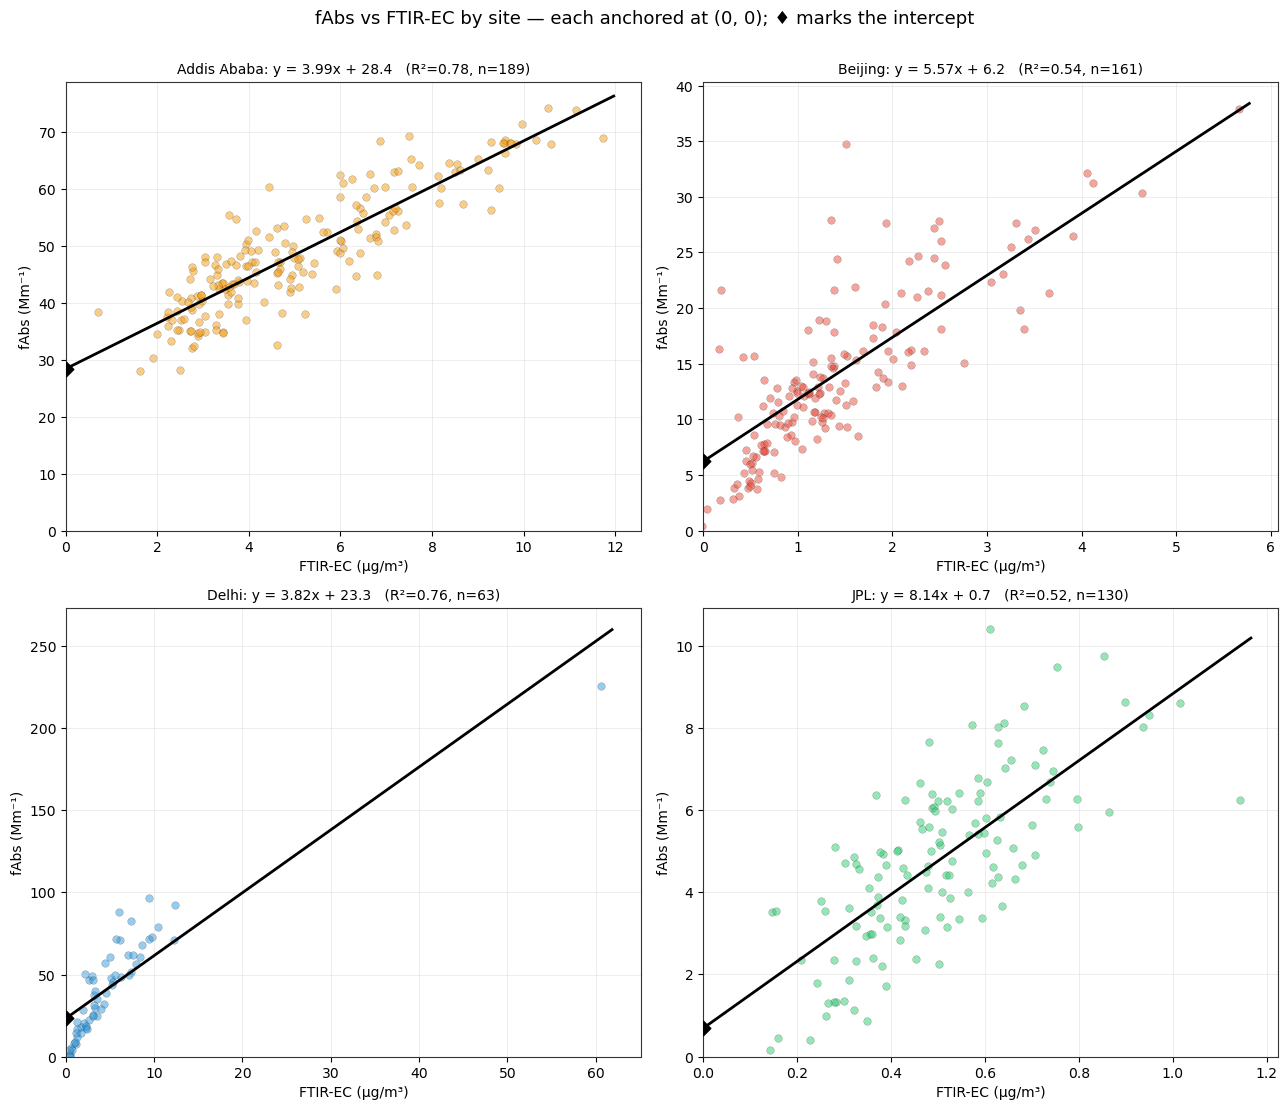

In [13]:
# (b) One panel per site, each anchored at (0, 0) with its own scale
fig, axs = plt.subplots(2, 2, figsize=(13, 11))
for axx, site in zip(axs.flat, order):
    v = site_fits[site]
    axx.scatter(v['x'], v['y'], s=30, alpha=0.5, color=v['color'], edgecolor='k', linewidth=0.2)
    xx = np.linspace(0, v['x'].max() * 1.02, 50)
    axx.plot(xx, v['slope'] * xx + v['intercept'], 'k-', lw=2)
    axx.scatter([0], [v['intercept']], color='k', marker='D', s=55, zorder=5)
    axx.set_xlim(0, None); axx.set_ylim(0, None)
    axx.axhline(0, color='grey', lw=0.6); axx.axvline(0, color='grey', lw=0.6)
    axx.set_title(f"{site.replace('_',' ')}: y = {v['slope']:.2f}x + {v['intercept']:.1f}   (R²={v['r2']:.2f}, n={v['n']})",
                  fontsize=10)
    axx.set_xlabel('FTIR-EC (µg/m³)'); axx.set_ylabel('fAbs (Mm⁻¹)')
fig.suptitle('fAbs vs FTIR-EC by site — each anchored at (0, 0); ♦ marks the intercept',
             fontsize=13, y=1.005)
plt.tight_layout(); plt.show()

**What the sites say.** JPL sits essentially **on the origin** (intercept ~0.7) but over a tiny EC
range; Beijing has a small offset (~6); Delhi is large (~23) but very scattered with no near-origin
points (the reason it's excluded); Addis has the **largest, best-constrained offset (~28)**. So the
offset is real and most pronounced exactly where the data are tight — which is why Addis is the one
site worth this exercise.

### Ethiopia only — raw vs additive-corrected, in the same panel style

Applying the additive correction (EC + Δ, Δ ≈ 7.11 µg/m³) to Addis and re-plotting in the per-site
style: both panels anchored at (0, 0), black fit line, ♦ marking the intercept. The correction slides
the cloud right and the fit drops onto the origin while keeping the same slope (MAC).

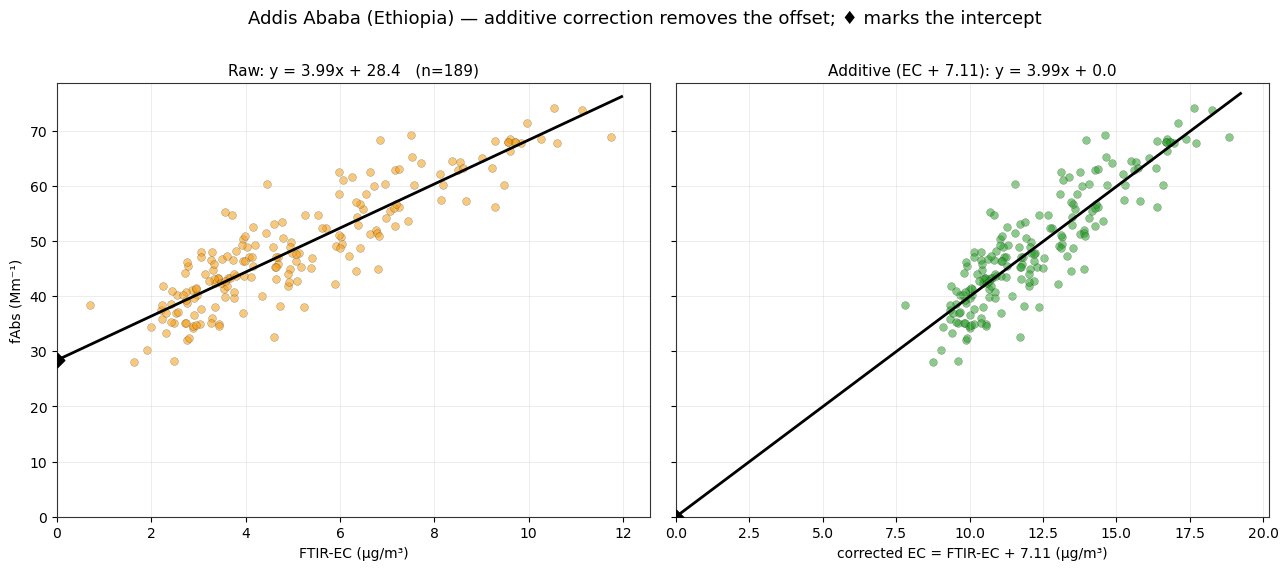

Additive Δ = 7.11 µg/m³  ->  intercept 28.4 → 0.00 Mm⁻¹, slope unchanged (3.99 → 3.99)


In [14]:
v = site_fits['Addis_Ababa']
xa, ya = v['x'], v['y']
xa_corr = xa + Delta                          # additive correction: EC + Δ
sc, bc = np.polyfit(xa_corr, ya, 1)           # re-fit after correction

panels = [
    (xa,      v['slope'],  v['intercept'],
     f"Raw: y = {v['slope']:.2f}x + {v['intercept']:.1f}   (n={v['n']})",
     v['color'], 'FTIR-EC (µg/m³)'),
    (xa_corr, sc, bc,
     f"Additive (EC + {Delta:.2f}): y = {sc:.2f}x + {bc:.1f}",
     'C2', f'corrected EC = FTIR-EC + {Delta:.2f} (µg/m³)'),
]

fig, axs = plt.subplots(1, 2, figsize=(13, 5.6), sharey=True)
for axx, (xv, sl, bb, title, col, xlab) in zip(axs, panels):
    axx.scatter(xv, ya, s=32, alpha=0.55, color=col, edgecolor='k', linewidth=0.2)
    xx = np.linspace(0, xv.max() * 1.02, 50)
    axx.plot(xx, sl * xx + bb, 'k-', lw=2)
    axx.scatter([0], [bb], color='k', marker='D', s=55, zorder=5)
    axx.set_xlim(0, None); axx.set_ylim(0, None)
    axx.axhline(0, color='grey', lw=0.6); axx.axvline(0, color='grey', lw=0.6)
    axx.set_title(title, fontsize=11); axx.set_xlabel(xlab)
axs[0].set_ylabel('fAbs (Mm⁻¹)')
fig.suptitle('Addis Ababa (Ethiopia) — additive correction removes the offset; ♦ marks the intercept',
             fontsize=13, y=1.01)
plt.tight_layout(); plt.show()
print(f"Additive Δ = {Delta:.2f} µg/m³  ->  intercept {v['intercept']:.1f} → {bc:.2f} Mm⁻¹, "
      f"slope unchanged ({v['slope']:.2f} → {sc:.2f})")

### All four sites — Addis additive-corrected, the others raw

Same 2×2 per-site grid as above, but **Addis is shown with the additive correction (EC + Δ)** while
Beijing, Delhi, and JPL stay raw. This lets you see Addis's offset removed (its ♦ drops to the origin)
against the other sites' untouched intercepts.

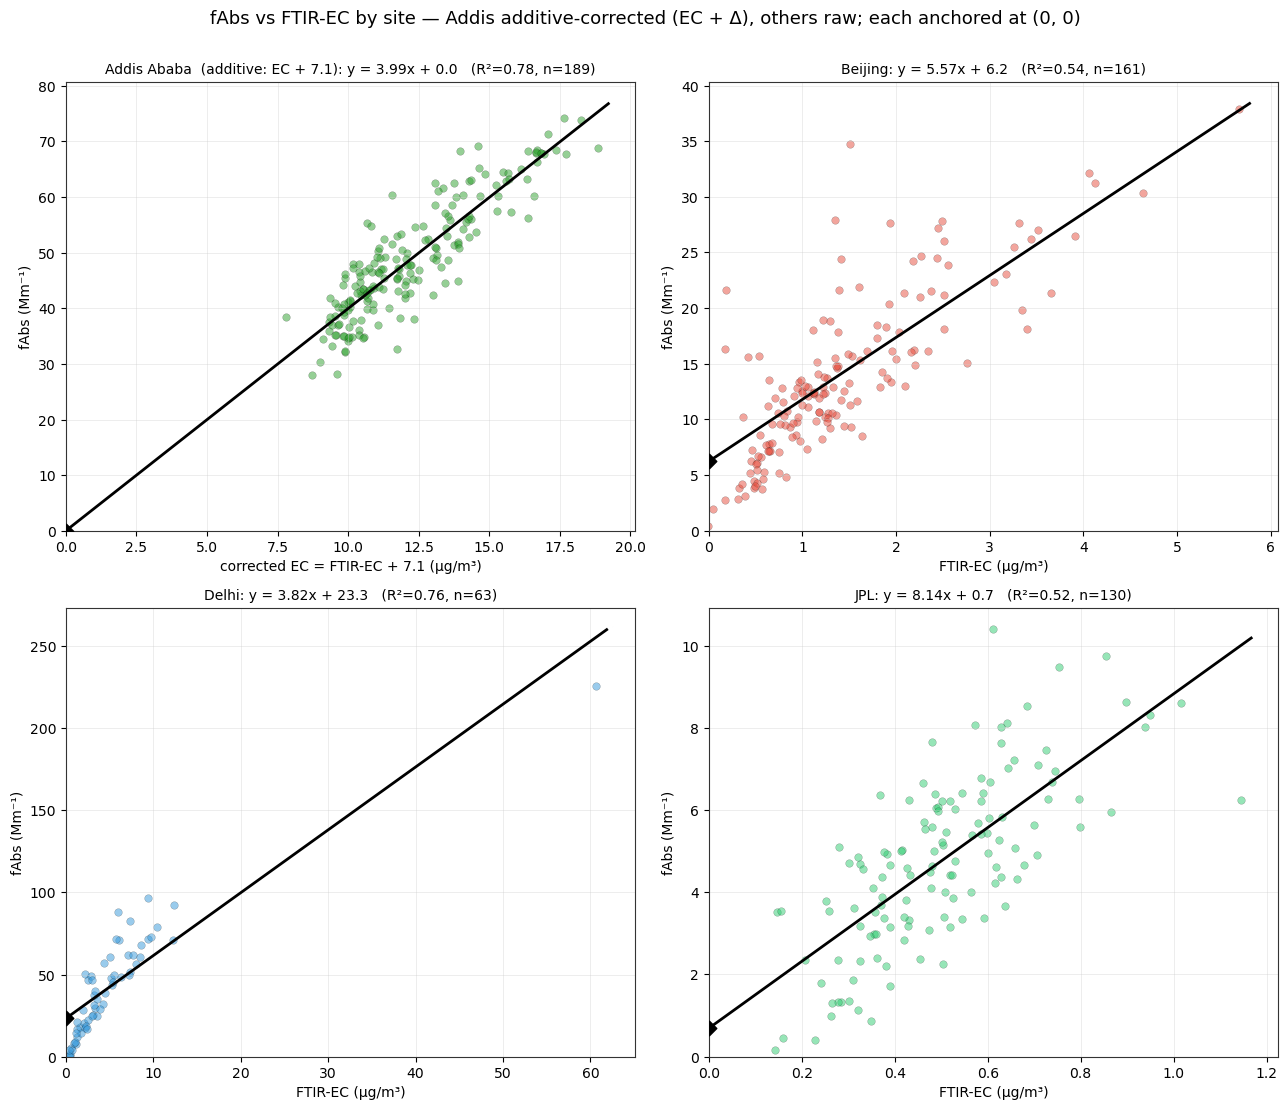

In [15]:
fig, axs = plt.subplots(2, 2, figsize=(13, 11))
for axx, site in zip(axs.flat, order):
    v = site_fits[site]
    if site == 'Addis_Ababa':
        xv = v['x'] + Delta                       # additive-corrected
        s, b = np.polyfit(xv, v['y'], 1)
        col, tag = 'C2', f'  (additive: EC + {Delta:.1f})'
        xlab = f'corrected EC = FTIR-EC + {Delta:.1f} (µg/m³)'
    else:
        xv = v['x']                                # raw
        s, b = v['slope'], v['intercept']
        col, tag = v['color'], ''
        xlab = 'FTIR-EC (µg/m³)'
    axx.scatter(xv, v['y'], s=30, alpha=0.5, color=col, edgecolor='k', linewidth=0.2)
    xx = np.linspace(0, xv.max() * 1.02, 50)
    axx.plot(xx, s * xx + b, 'k-', lw=2)
    axx.scatter([0], [b], color='k', marker='D', s=55, zorder=5)
    axx.set_xlim(0, None); axx.set_ylim(0, None)
    axx.axhline(0, color='grey', lw=0.6); axx.axvline(0, color='grey', lw=0.6)
    axx.set_title(f"{site.replace('_',' ')}{tag}: y = {s:.2f}x + {b:.1f}   (R²={v['r2']:.2f}, n={v['n']})",
                  fontsize=10)
    axx.set_xlabel(xlab); axx.set_ylabel('fAbs (Mm⁻¹)')
fig.suptitle('fAbs vs FTIR-EC by site — Addis additive-corrected (EC + Δ), others raw; each anchored at (0, 0)',
             fontsize=13, y=1.005)
plt.tight_layout(); plt.show()

## What about both — a multiplicative *and* additive correction?

Allow a general affine correction **EC′ = k·EC + Δ** (both a multiplier and a constant). Re-fitting
fAbs on EC′:

$$\text{slope}' = \frac{\text{slope}}{k}, \qquad
  \text{intercept}' = \text{offset} - \frac{\text{slope}}{k}\,\Delta .$$

Setting the intercept to zero gives **Δ = k · (offset / slope) = k · 7.11**. Two consequences:

1. **You can always zero the offset once an additive term is allowed** — for *any* multiplier k, the
   additive Δ = k·7.11 does it.
2. **The multiplier k is then free; it only rescales the slope** (to slope/k). It contributes nothing
   to removing the offset.

So combining the two does **not** rescue the multiplicative idea. The additive part does all the
offset-removal, and it never goes away — in fact the constant added to every filter *grows* with k
(Δ = k·7.11 ≥ 7.11). There is no purely- or even mostly-multiplicative escape from a constant
per-filter EC correction.

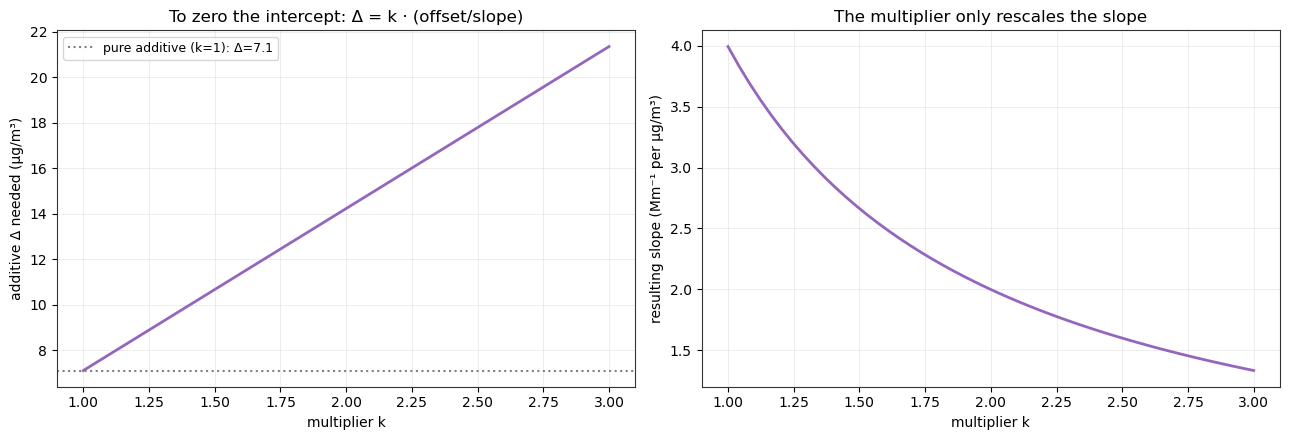

Example: EC' = 1.5·EC + 10.67
  refit -> slope 2.663, intercept 0.000
  (intercept ~0 by construction; slope = 3.99/1.5 = 2.66)
  constant added to EVERY filter = 10.67 µg/m³  (vs 7.11 for pure additive)


In [16]:
ks = np.linspace(1, 3, 50)
need_delta = ks * (offset / slope)        # additive needed to zero the intercept, per multiplier
res_slope = slope / ks                     # resulting corrected slope

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].plot(ks, need_delta, 'C4-', lw=2)
ax[0].axhline(offset / slope, ls=':', c='grey', label=f'pure additive (k=1): Δ={offset/slope:.1f}')
ax[0].set_xlabel('multiplier k'); ax[0].set_ylabel('additive Δ needed (µg/m³)')
ax[0].set_title('To zero the intercept: Δ = k · (offset/slope)'); ax[0].legend(fontsize=9)
ax[1].plot(ks, res_slope, 'C4-', lw=2)
ax[1].set_xlabel('multiplier k'); ax[1].set_ylabel('resulting slope (Mm⁻¹ per µg/m³)')
ax[1].set_title('The multiplier only rescales the slope')
plt.tight_layout(); plt.show()

# Concrete combined example: a modest k=1.5 plus the additive it then requires
k_ex = 1.5
d_ex = k_ex * (offset / slope)
se, be = np.polyfit(k_ex * x + d_ex, y, 1)
print(f"Example: EC' = {k_ex}·EC + {d_ex:.2f}")
print(f"  refit -> slope {se:.3f}, intercept {be:.3f}")
print(f"  (intercept ~0 by construction; slope = {slope:.2f}/{k_ex} = {slope/k_ex:.2f})")
print(f"  constant added to EVERY filter = {d_ex:.2f} µg/m³  (vs {offset/slope:.2f} for pure additive)")

## Conclusion

- **The offset is ~28 Mm⁻¹** (OLS) and ~26 Mm⁻¹ under the Deming errors-in-variables fit — it is a
  genuine feature, not just an artifact of ignoring X-error. Across sites it is largest and
  best-constrained at Addis; JPL passes through the origin and Beijing's is small.
- **To remove it you need a constant additive shift** of ~7 µg/m³ added to *every* filter
  (Δ = offset / slope). That keeps the slope (~4 Mm⁻¹ per µg/m³, the MAC) and lands the line on the
  origin.
- **A multiplicative correction cannot remove the offset** — it leaves the intercept at ~28 and only
  flattens the slope. So a constant-factor underestimate of EC by FTIR would show up as a wrong MAC,
  **not** as the offset we see.
- **Allowing both (EC′ = k·EC + Δ) doesn't change the verdict.** The offset is zeroed only by the
  additive part (Δ = k·7.11); the multiplier is free and just rescales the slope. Every member of the
  family still adds a constant ≥7 µg/m³ to every filter — there is no mostly-multiplicative escape.
- The required additive shift (~7 µg/m³) is **larger than the mean EC**, so attributing it to uniform
  missing char is physically hard: it would mean even the cleanest filters are missing ~7 µg/m³ of
  fully-charred carbon. The "≈2.4× at the mean" framing is the same shift expressed as a ratio and
  should not be read as a multiplier that fixes the data.

**Takeaway for the meeting:** the offset demands a *constant* additive EC correction, and its size makes
the simple "FTIR misses char" story a stretch — worth weighing against other explanations for the
intercept.